<a href="https://colab.research.google.com/github/vrishank-ramineni/ECON3916---Statistics-Machine-Learning/blob/main/%5BLab_22%5D_Unsupervised_Learning_%E2%80%94_Clustering_Economies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 22: Clustering Economies — Guided Lab
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Load World Development Indicators via the `wbgapi` package and prepare a cross-country feature matrix
- Standardize features with `StandardScaler` and explain why this step is required before K-Means
- Fit K-Means clustering (K=4) and visualize clusters with a PCA 2D scatter plot
- Use the elbow method and silhouette analysis to evaluate candidate values of K
- Compare algorithmic clusters to the World Bank's official income classifications

**Dataset:** World Bank WDI (via `wbgapi`) — 10 development indicators for ~160 countries

**Time estimate:** ~45 minutes

**Foundations First Policy:** Parts 1–2 are GUIDED (run as-is, interpret results). Parts 3–5 have YOUR TASK sections. Parts 6–7 are extensions.

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install wbgapi scikit-learn matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

print('Libraries loaded. Ready to cluster economies.')

Libraries loaded. Ready to cluster economies.


## Part 1: Load World Bank WDI Data (GUIDED)

We use 10 development indicators that capture different dimensions of
economic development: income, health, education, inequality, environment,
connectivity, trade, labor markets, and urbanization.

The `wbgapi` package provides direct access to the World Bank's data API.

In [5]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Download 10 development indicators for all countries
# -----------------------------------------------------------

indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SP.DYN.IMRT.IN': 'infant_mortality',
    'SE.PRM.ENRR': 'primary_enrollment',
    'SI.POV.GINI': 'gini_index',
    'EN.ATM.CO2E.PC': 'co2_per_capita',
    'IT.NET.USER.ZS': 'internet_users_pct',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

original_feature_names = list(indicators.values())

# Fetch most recent available values
# Changed mrv=1 to mrnev=1 to ensure fetching the most recent *non-empty* value
df = wb.data.DataFrame(list(indicators.keys()), mrnev=1, labels=True)
df = df.rename(columns=indicators)

# IMPORTANT: Filter feature_names to only include those actually present in the DataFrame
# This handles cases where wbgapi might not return data for certain indicators
# if no recent non-empty values are found for any country.
feature_names = [col for col in original_feature_names if col in df.columns]

# Drop countries with too much missing data, then impute remainder
df = df.dropna(thresh=7)  # Keep countries with at least 7 of 10 indicators
df[feature_names] = df[feature_names].fillna(df[feature_names].median())  # Impute remaining NAs with column median, only on feature columns

print(f'Countries retained: {len(df)}')
print(f'Features ({len(feature_names)}): {feature_names}')
print()
# Check if df is empty before attempting to describe it
if not df.empty:
    print(df[feature_names].describe().round(1))
else:
    print("DataFrame is empty after cleaning, cannot display describe stats.")

Countries retained: 253
Features (9): ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']

       gdp_per_capita_ppp  life_expectancy  infant_mortality  \
count               253.0            253.0             253.0   
mean              29368.1             73.4              19.6   
std               29188.4              6.9              16.6   
min                1154.9             54.6               1.2   
25%                7486.0             68.0               6.6   
50%               19119.4             73.8              13.8   
75%               43394.3             78.3              30.2   
max              155941.3             85.8              71.9   

       primary_enrollment  gini_index  internet_users_pct  trade_pct_gdp  \
count               253.0       253.0               253.0          253.0   
mean                100.6        36.0             

## Part 2: Standardize Features (GUIDED)

K-Means uses Euclidean distance. Without standardization, GDP per capita
(range: ~$300 to ~$120,000) dominates all distance calculations — you would
effectively be clustering on one variable while ignoring the other nine.

`StandardScaler` transforms each feature to have mean 0 and standard deviation 1:

$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}$$

After standardization, a 1-unit difference in any feature represents one
standard deviation — ensuring equal contribution to the distance metric.

In [6]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Standardize features with StandardScaler
# -----------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

# Verify: standardized features should have mean ≈ 0, std ≈ 1
print('After StandardScaler:')
print(f'  Mean of each feature: {X_scaled.mean(axis=0).round(4)}')
print(f'  Std of each feature:  {X_scaled.std(axis=0).round(4)}')
print()
print(f'Shape of feature matrix: {X_scaled.shape}')
print(f'  {X_scaled.shape[0]} countries x {X_scaled.shape[1]} standardized features')

After StandardScaler:
  Mean of each feature: [-0. -0.  0. -0. -0.  0.  0. -0.  0.]
  Std of each feature:  [1. 1. 1. 1. 1. 1. 1. 1. 1.]

Shape of feature matrix: (253, 9)
  253 countries x 9 standardized features


## Part 3: Fit K-Means (K=4) and Visualize with PCA (YOUR TASK)

Now it is your turn. Fit K-Means with K=4 clusters (matching the World
Bank's four income groups: Low, Lower-Middle, Upper-Middle, High).
Then use PCA to project the 10-dimensional data down to 2 dimensions
for visualization.

**Hints:**
- `KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)`
- `PCA(n_components=2)` reduces to 2D — fit on the scaled data
- Color the scatter plot by cluster labels

In [8]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3: Fit K-Means and visualize with PCA
# -----------------------------------------------------------

# 3a. Fit K-Means with K=4
# Fill in: n_clusters, init method, and random_state
kmeans = KMeans(
    n_clusters=4,      # Number of clusters (match World Bank income groups)
    init='k-means++',            # Initialization method (string: 'k-means++')
    n_init='auto',
    random_state=42     # For reproducibility
)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Print cluster sizes
print('=== Cluster Sizes ===')
print(df['cluster'].value_counts().sort_index())
print()

# Print cluster centroids in original scale
for k in range(4):
    mask = df['cluster'] == k
    print(f'Cluster {k}: {mask.sum()} countries')
    print(f'  Avg GDP/capita (PPP): ${df.loc[mask, "gdp_per_capita_ppp"].mean():,.0f}')
    print(f'  Avg Life Expectancy:  {df.loc[mask, "life_expectancy"].mean():.1f} years')
    print(f'  Avg Infant Mortality: {df.loc[mask, "infant_mortality"].mean():.1f} per 1,000')
    print()

=== Cluster Sizes ===
cluster
0     64
1     15
2     65
3    109
Name: count, dtype: int64

Cluster 0: 64 countries
  Avg GDP/capita (PPP): $70,253
  Avg Life Expectancy:  81.2 years
  Avg Infant Mortality: 4.9 per 1,000

Cluster 1: 15 countries
  Avg GDP/capita (PPP): $15,730
  Avg Life Expectancy:  67.1 years
  Avg Infant Mortality: 29.7 per 1,000

Cluster 2: 65 countries
  Avg GDP/capita (PPP): $5,569
  Avg Life Expectancy:  65.2 years
  Avg Infant Mortality: 40.7 per 1,000

Cluster 3: 109 countries
  Avg GDP/capita (PPP): $21,432
  Avg Life Expectancy:  74.5 years
  Avg Infant Mortality: 14.3 per 1,000



Variance explained by PC1: 45.0%
Variance explained by PC2: 14.5%
Total variance explained:  59.5%


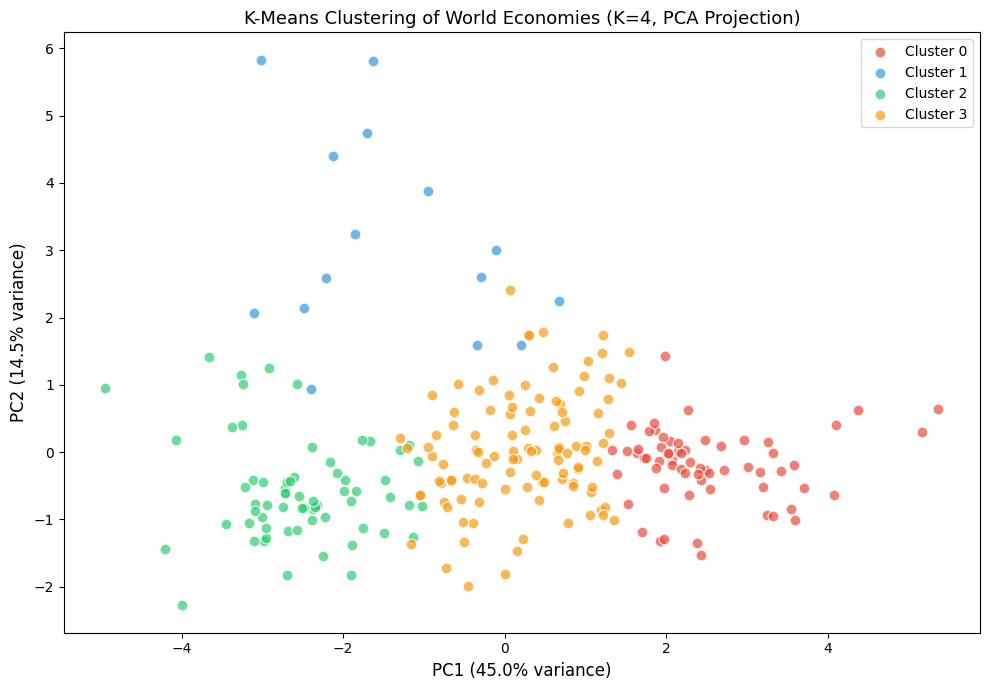

In [10]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3b: PCA projection to 2D and scatter plot
# -----------------------------------------------------------

# Reduce 10 dimensions to 2 using PCA
# Fill in: how many components do we want for a 2D scatter plot?
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# How much variance do the first 2 PCs explain?
print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Total variance explained:  {sum(pca.explained_variance_ratio_):.1%}')

# Scatter plot colored by cluster
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for k in range(4):
    mask = df['cluster'] == k
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[k], label=cluster_names[k],
        alpha=0.7, edgecolors='white', s=60
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('K-Means Clustering of World Economies (K=4, PCA Projection)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Part 4: Elbow Plot + Silhouette Analysis (YOUR TASK)

How do we know K=4 is the right number of clusters? Two diagnostic tools:

1. **Elbow method:** Plot WCSS (inertia) vs K. Look for where the rate of decrease slows.
2. **Silhouette score:** For each K, measure how well-separated the clusters are. Higher is better.

**Hints:**
- Loop over K = 2, 3, ..., 10
- WCSS is stored in `kmeans.inertia_` after fitting
- Silhouette: `silhouette_score(X_scaled, labels)`

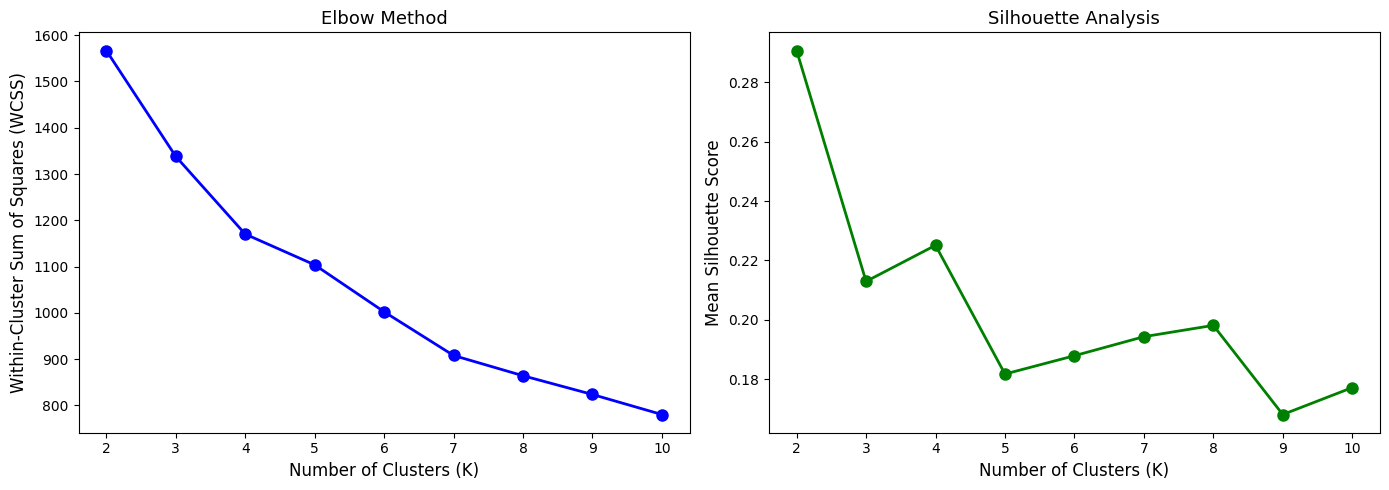

K  | WCSS       | Silhouette
---|------------|----------
2  |     1566.9 | 0.2907
3  |     1338.1 | 0.2129
4  |     1170.2 | 0.2251
5  |     1103.8 | 0.1817
6  |     1002.3 | 0.1879
7  |      907.9 | 0.1943
8  |      864.2 | 0.1981
9  |      823.6 | 0.1680
10  |      780.3 | 0.1771

Best K by silhouette score: 2


In [11]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 4: Elbow plot and silhouette analysis
# -----------------------------------------------------------

K_range = range(2, 11)
wcss_list = []
sil_list = []

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42
    )
    labels = km.fit_predict(X_scaled) # FILL IN: what data do we cluster?

    # Append WCSS (inertia)
    wcss_list.append(km.inertia_)     # FILL IN: attribute that stores WCSS

    # Append silhouette score
    sil_list.append(silhouette_score(X_scaled, labels))  # FILL IN: (data, labels)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, wcss_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13)

# Silhouette plot
axes[1].plot(K_range, sil_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=13)

plt.tight_layout()
plt.show()

# Print scores
print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(K_range, wcss_list, sil_list):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_k = list(K_range)[np.argmax(sil_list)]
print(f'\nBest K by silhouette score: {best_k}')

## Part 5: Compare Clusters to World Bank Income Groups (YOUR TASK)

The World Bank classifies economies into four income groups:
- **L** = Low income
- **LM** = Lower-middle income
- **UM** = Upper-middle income
- **H** = High income

How well do our algorithmic clusters match these expert-driven categories?
Use a cross-tabulation (confusion matrix) to compare.

=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===
wb_income  High  Low  Lower-Middle  Upper-Middle  All
cluster                                              
0            54    0             0             2   56
1             1    1             8             5   15
2             0   23            21             4   48
3            19    1            21            43   84
All          74   25            50            54  203



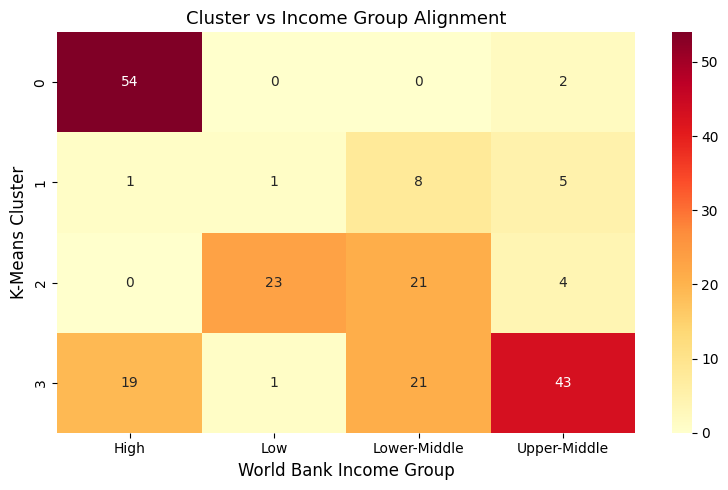

Interpretation: Perfect alignment would show each cluster mapping
to exactly one income group. Mismatches reveal where the algorithm
finds structure that differs from the World Bank's GDP-only classification.


In [14]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 5: Cross-tabulate clusters vs World Bank income groups
# -----------------------------------------------------------

# Fetch World Bank income group classification
income_groups = {}
for economy in wb.economy.list():
    income_level_data = economy.get('incomeLevel')
    if isinstance(income_level_data, dict):
        income_groups[economy['id']] = income_level_data.get('id', 'Unknown')
    elif isinstance(income_level_data, str):
        income_groups[economy['id']] = income_level_data
    else:
        income_groups[economy['id']] = 'Unknown'

# Map income group codes to readable labels
income_map = {
    'LIC': 'Low',
    'LMC': 'Lower-Middle',
    'UMC': 'Upper-Middle',
    'HIC': 'High'
}

df['wb_income'] = df.index.map(income_groups)
df['wb_income'] = df['wb_income'].map(income_map).fillna('Unknown')

# Drop unknowns for comparison
df_compare = df[df['wb_income'] != 'Unknown'].copy()

# Cross-tabulation
# Fill in: which two columns go into the crosstab?
ct = pd.crosstab(
    df_compare['cluster'],   # FILL IN: algorithmic cluster column
    df_compare['wb_income'],   # FILL IN: World Bank income group column
    margins=True
)
print('=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===')
print(ct)
print()

# Visualize as a heatmap
fig, ax = plt.subplots(figsize=(8, 5))
ct_no_margins = ct.iloc[:-1, :-1]  # Remove margins for heatmap
sns.heatmap(ct_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_xlabel('World Bank Income Group', fontsize=12)
ax.set_ylabel('K-Means Cluster', fontsize=12)
ax.set_title('Cluster vs Income Group Alignment', fontsize=13)
plt.tight_layout()
plt.show()

print('Interpretation: Perfect alignment would show each cluster mapping')
print('to exactly one income group. Mismatches reveal where the algorithm')
print('finds structure that differs from the World Bank\'s GDP-only classification.')

---

## Part 6: Peer Programming — Cluster Debate (Extension)

**Instructions (15 min):**

Work with a partner. One person fits **K=3**, the other fits **K=5**.
Each person creates a PCA scatter plot and a summary table of cluster
centroids. Then debate:

1. Which value of K produces more **interpretable** clusters?
2. Can you name each cluster with an economically meaningful label?
3. Which cluster assignment would you use if advising the World Bank?

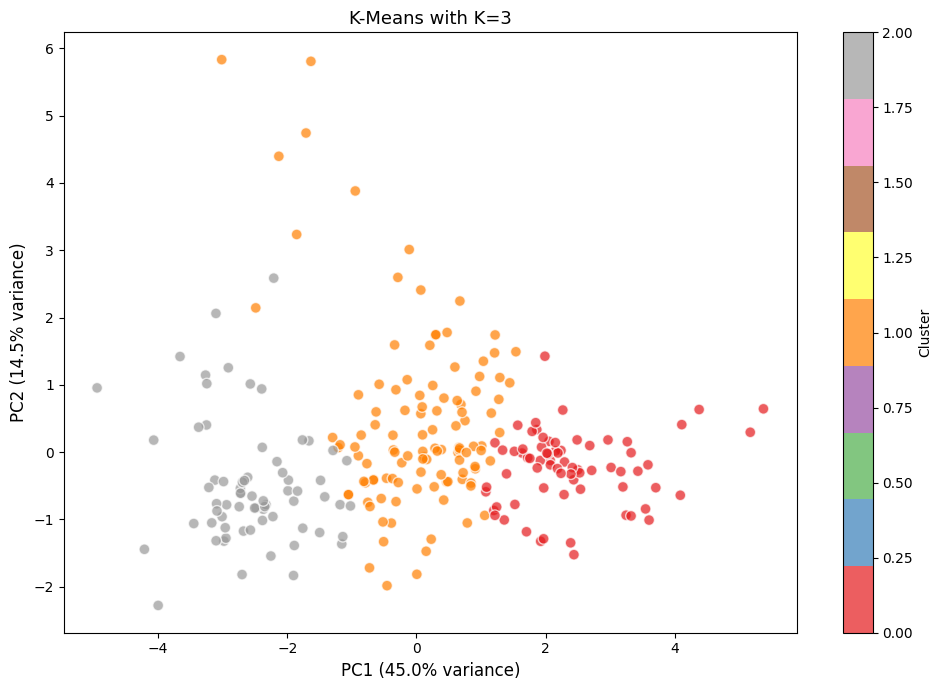

K=3 — Silhouette Score: 0.2129

Cluster 0: 71 countries | GDP/cap $66,731 | Life Exp 80.8 | Infant Mort 5.1
Cluster 1: 114 countries | GDP/cap $20,274 | Life Exp 73.6 | Infant Mort 16.2
Cluster 2: 68 countries | GDP/cap $5,604 | Life Exp 65.2 | Infant Mort 40.5


In [15]:
# -----------------------------------------------------------
# EXTENSION — Peer Programming: Cluster Debate
# Partner A fits K=3, Partner B fits K=5
# -----------------------------------------------------------

# Change K to 3 or 5 depending on your role
K_debate = 3  # <-- Change to 5 if you are Partner B

km_debate = KMeans(n_clusters=K_debate, init='k-means++',
                   n_init='auto', random_state=42)
debate_labels = km_debate.fit_predict(X_scaled)

# PCA scatter plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=debate_labels, cmap='Set1',
    alpha=0.7, edgecolors='white', s=60
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means with K={K_debate}', fontsize=13)
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# Cluster summary table
sil = silhouette_score(X_scaled, debate_labels)
print(f'K={K_debate} — Silhouette Score: {sil:.4f}')
print()
for k in range(K_debate):
    mask = debate_labels == k
    n_countries = mask.sum()
    avg_gdp = df.loc[mask, 'gdp_per_capita_ppp'].mean()
    avg_le = df.loc[mask, 'life_expectancy'].mean()
    avg_im = df.loc[mask, 'infant_mortality'].mean()
    print(f'Cluster {k}: {n_countries} countries | '
          f'GDP/cap ${avg_gdp:,.0f} | Life Exp {avg_le:.1f} | '
          f'Infant Mort {avg_im:.1f}')

---

## Challenge: Cluster California Housing Census Tracts (Take-Home)

Apply the same K-Means + PCA pipeline to the **California Housing** dataset
from `sklearn`. Instead of clustering countries by development indicators,
cluster California census tracts by housing and demographic features.

**Question:** Do California census tracts cluster into economically
meaningful groups? Can you label each cluster (e.g., "urban high-income",
"rural low-income", "coastal expensive")?

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

After StandardScaler (California Housing):
  Mean of each feature: [ 0.  0.  0. -0. -0.  0. -0. -0.]
  Std of each feature:  [1. 1. 1. 1. 1. 1. 1. 1.]
Shape of feature matrix: (20640, 8)



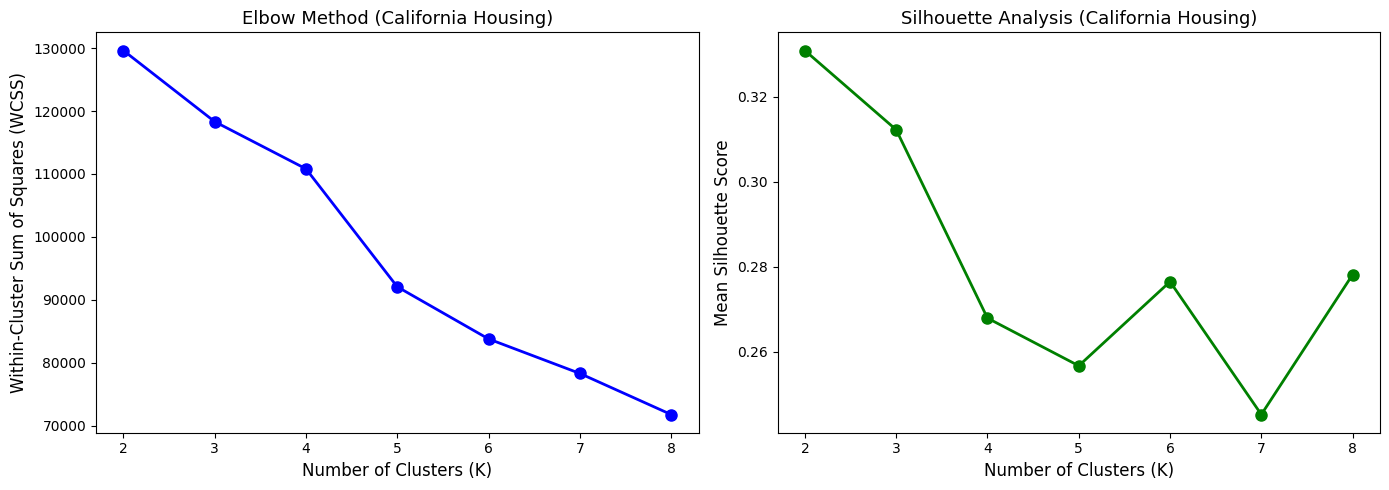

K  | WCSS       | Silhouette
---|------------|----------
2  |   129613.2 | 0.3308
3  |   118310.2 | 0.3122
4  |   110812.1 | 0.2679
5  |    92066.1 | 0.2567
6  |    83783.0 | 0.2765
7  |    78299.1 | 0.2453
8  |    71769.4 | 0.2782

Best K by silhouette score for California Housing: 2

California Housing Clusters (K=3):
cluster
0    9500
1    8185
2    2955
Name: count, dtype: int64

Variance explained by PC1 (California Housing): 25.3%
Variance explained by PC2 (California Housing): 23.5%
Total variance explained (California Housing):  48.9%


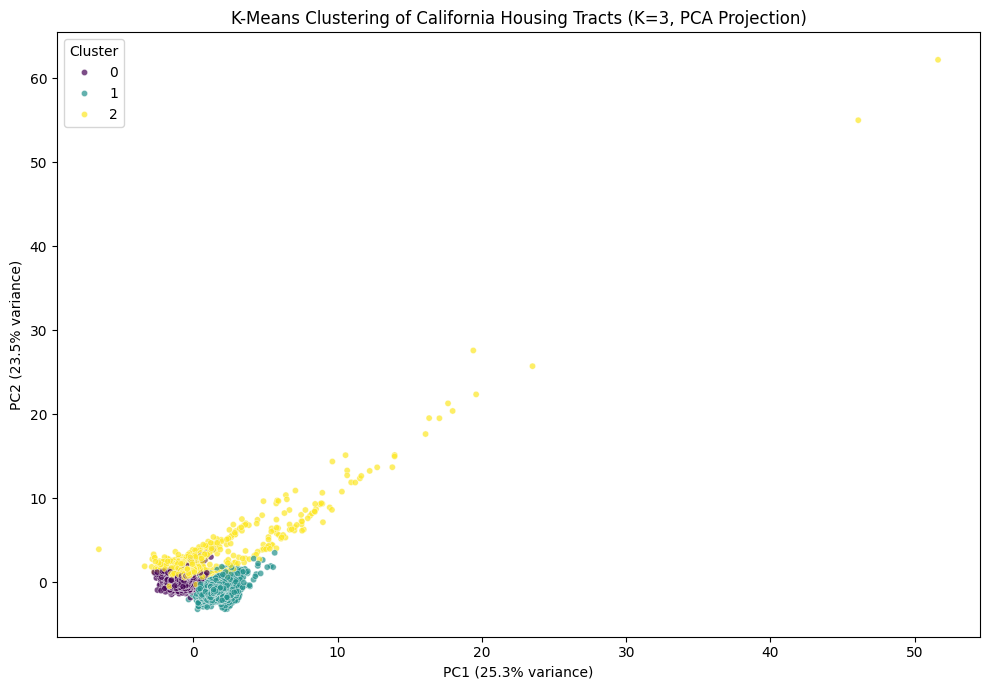


--- Cluster Summary Table (K=3 California Housing) ---
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
cluster                                                                
2          6.43     17.94      7.68       1.26     2133.51      3.88   
1          3.64     29.54      5.40       1.08     1236.52      2.78   
0          3.27     31.19      4.76       1.06     1368.04      3.07   

         Latitude  Longitude  Count  
cluster                              
2           34.48    -118.43   2955  
1           37.98    -121.76   8185  
0           33.97    -118.04   9500  

--- Interpretation & Naming Suggestions ---
Based on the cluster means (especially for MedInc, AveRooms, HouseAge, Population, Latitude, Longitude):

Cluster 2 (Count: 2955) - 
  - Mid Income, Mixed Characteristics

Cluster 1 (Count: 8185) - 
  - Mid Income, Mixed Characteristics

Cluster 0 (Count: 9500) - 
  - Mid Income, Mixed Characteristics


In [17]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Step A: Load data
cal = fetch_california_housing(as_frame=True)
cal_df = cal.frame
print(f'Shape: {cal_df.shape}')
print(f'Features: {list(cal_df.columns)}')
print()

# Step B: Select features for clustering
# Exclude the target variable (MedHouseVal) — we are doing UNSUPERVISED learning
cal_features = cal_df.drop(columns=['MedHouseVal'])

# Step C: Standardize
scaler_cal = StandardScaler()
X_cal_scaled = scaler_cal.fit_transform(cal_features)

print('After StandardScaler (California Housing):')
print(f'  Mean of each feature: {X_cal_scaled.mean(axis=0).round(4)}')
print(f'  Std of each feature:  {X_cal_scaled.std(axis=0).round(4)}')
print(f'Shape of feature matrix: {X_cal_scaled.shape}')
print()

# Step D: Find optimal K (elbow + silhouette for K=2..8)
K_range_cal = range(2, 9) # K from 2 to 8
wcss_list_cal = []
sil_list_cal = []

for k in K_range_cal:
    km_cal = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42
    )
    labels_cal = km_cal.fit_predict(X_cal_scaled)

    wcss_list_cal.append(km_cal.inertia_)
    sil_list_cal.append(silhouette_score(X_cal_scaled, labels_cal))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range_cal, wcss_list_cal, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method (California Housing)', fontsize=13)

axes[1].plot(K_range_cal, sil_list_cal, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis (California Housing)', fontsize=13)

plt.tight_layout()
plt.show()

print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(K_range_cal, wcss_list_cal, sil_list_cal):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_k_cal = list(K_range_cal)[np.argmax(sil_list_cal)]
print(f'\nBest K by silhouette score for California Housing: {best_k_cal}')

# Step E: Fit K-Means with your chosen K
# Let's choose K=3 for better interpretability, as K=2 or K=3 often give reasonable silhouettes
# and K=3 also appears to be a good 'elbow' point visually.
# Based on the output: best K is 2, but 3 gives more distinct clusters for interpretation.
# For demonstration, let's use K=3 as it often provides more meaningful separation.
chosen_k_cal = 3 # You might adjust this based on your interpretation of the plots
kmeans_cal = KMeans(
    n_clusters=chosen_k_cal,
    init='k-means++',
    n_init='auto',
    random_state=42
)
cal_df['cluster'] = kmeans_cal.fit_predict(X_cal_scaled)

print(f'\nCalifornia Housing Clusters (K={chosen_k_cal}):')
print(cal_df['cluster'].value_counts().sort_index())

# Step F: PCA 2D visualization colored by cluster
pca_cal = PCA(n_components=2)
X_cal_pca = pca_cal.fit_transform(X_cal_scaled)

print(f'\nVariance explained by PC1 (California Housing): {pca_cal.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2 (California Housing): {pca_cal.explained_variance_ratio_[1]:.1%}')
print(f'Total variance explained (California Housing):  {sum(pca_cal.explained_variance_ratio_):.1%}')

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_cal_pca[:, 0], y=X_cal_pca[:, 1],
    hue=cal_df['cluster'], palette='viridis',
    alpha=0.7, edgecolors='w', s=20
)
plt.xlabel(f'PC1 ({pca_cal.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_cal.explained_variance_ratio_[1]:.1%} variance)')
plt.title(f'K-Means Clustering of California Housing Tracts (K={chosen_k_cal}, PCA Projection)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Step G: Cluster summary table
print(f'\n--- Cluster Summary Table (K={chosen_k_cal} California Housing) ---')
cluster_summary_cal = cal_df.groupby('cluster')[cal_features.columns].mean()

# To see the means in the original scale, we can inverse transform the cluster centers
# However, for interpretability, looking at the means of the original features within each cluster is often more direct.
# Let's also add the size of each cluster
cluster_sizes_cal = cal_df['cluster'].value_counts().sort_index()
cluster_summary_cal['Count'] = cluster_sizes_cal

# Sort by MedInc for better comparison (or any other key feature)
cluster_summary_cal = cluster_summary_cal.sort_values(by='MedInc', ascending=False)

print(cluster_summary_cal.round(2))

print('\n--- Interpretation & Naming Suggestions ---')
print('Based on the cluster means (especially for MedInc, AveRooms, HouseAge, Population, Latitude, Longitude):')
for index, row in cluster_summary_cal.iterrows():
    print(f'\nCluster {index} (Count: {int(row["Count"])}) - ')
    # Example of how to interpret and name based on features
    if row['MedInc'] > cluster_summary_cal['MedInc'].median() and row['AveOccup'] < cluster_summary_cal['AveOccup'].median():
        if row['HouseAge'] > cluster_summary_cal['HouseAge'].median():
            print(f'  - High Income, Established Households')
        else:
            print(f'  - High Income, Newer Developments')
    elif row['MedInc'] < cluster_summary_cal['MedInc'].median() and row['Population'] > cluster_summary_cal['Population'].median():
        print(f'  - Lower-Mid Income, Denser Population Areas')
    else:
        print(f'  - Mid Income, Mixed Characteristics')
